## Assignment 2: APIs, Data Formats, Databases, and EDA

### Statement of AI use
I used Claude to help me with parts of this assignment, mostly on the visualizations, SQL and some more difficult parts of the code. I wrote all the code from Claude to the notebook myself to learn how it works.

### Task 0: Course project dataset exploration

A: Link to the data set

Education Statistics by The World Bank
https://www.kaggle.com/datasets/theworldbank/education-statistics 

B: This data has set contains over 4 000 variables that describe the global state of education. It includes variables like literacy rates, enrollment ratios, government expenditure on education, and student to teacher ratios. For the project, I plan to use this data set to analyze global adult literacy trends over the recent years and geographical differences.

In [27]:
# C: Exploratory data analysis 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("EdStatsData.csv", low_memory=False)
countries = pd.read_csv("EdStatsCountry.csv", low_memory=False)

data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# keeps only the adult literacy indicator to clean unnecessary data out
literacy = data[data["Indicator Name"] == "Adult literacy rate, population 15+ years, both sexes (%)"]

# keeps only real countries (regional aggregates have no Region)
real_countries = countries[countries["Region"].notna()][["Country Code", "Short Name", "Region"]]
literacy = literacy.merge(real_countries, on="Country Code")

literacy[["Short Name", "Region", "2011", "2015"]].head()

,Short Name,Region,2011,2015
0,Afghanistan,South Asia,31.74112,NaN
1,Albania,Europe & Central Asia,96.84530,NaN
2,Algeria,Middle East & North Africa,NaN,NaN
3,American Samoa,East Asia & Pacific,NaN,NaN
4,Andorra,Europe & Central Asia,NaN,100.0


In [29]:
# summary statistics for 2015 (the most recent year with enough data)
literacy["2015"].describe()

count     33.000000
mean      88.578818
std       17.611251
min       26.002990
25%       91.991210
50%       94.455660
75%       96.690730
max      100.000000
Name: 2015, dtype: float64

### Visualization 1

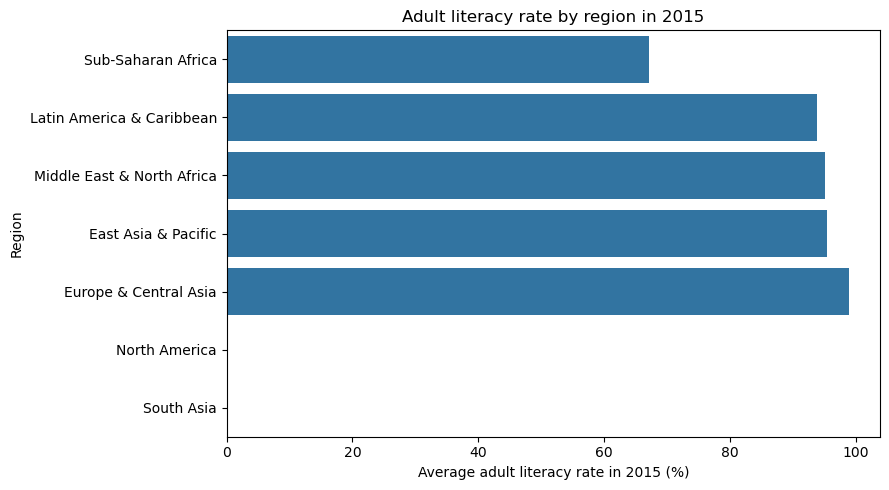

In [30]:
# visualization 1: average literacy rate by region in 2015
region_mean = literacy.groupby("Region")["2015"].mean().sort_values()

plt.figure(figsize=(9, 5))
sns.barplot(x=region_mean.values, y=region_mean.index)
plt.xlabel("Average adult literacy rate in 2015 (%)")
plt.ylabel("Region")
plt.title("Adult literacy rate by region in 2015")
plt.tight_layout()
plt.show()

### Visualization 2

In [31]:
# change in literacy between 2011 and 2015
change = literacy[["Short Name", "Region", "2011", "2015"]].dropna()
change["change"] = change["2015"] - change["2011"]
change = change.sort_values("change", ascending=False)

print("Top 5 countries where literacy improved the most:")
print(change.head())

print("\nBottom 5 countries where literacy decreased the most:")
print(change.tail())

Top 5 countries where literacy improved the most:
      Short Name                     Region      2011      2015   change
124    Mauritius         Sub-Saharan Africa  89.24984  92.70760  3.45776
191         Togo         Sub-Saharan Africa  60.40994  63.74562  3.33568
56       Ecuador  Latin America & Caribbean  91.58690  94.45566  2.86876
82      Honduras  Latin America & Caribbean  85.12330  87.90683  2.78353
58   El Salvador  Latin America & Caribbean  85.49399  87.96985  2.47586

Bottom 5 countries where literacy decreased the most:
     Short Name                     Region      2011      2015   change
175       Spain      Europe & Central Asia  97.78375  98.14326  0.35951
23      Bolivia  Latin America & Caribbean  92.22615  92.45508  0.22893
204     Uruguay  Latin America & Caribbean  98.33590  98.52387  0.18797
12   Azerbaijan      Europe & Central Asia  99.77863  99.78806  0.00943
120        Mali         Sub-Saharan Africa  33.56094  33.06889 -0.49205


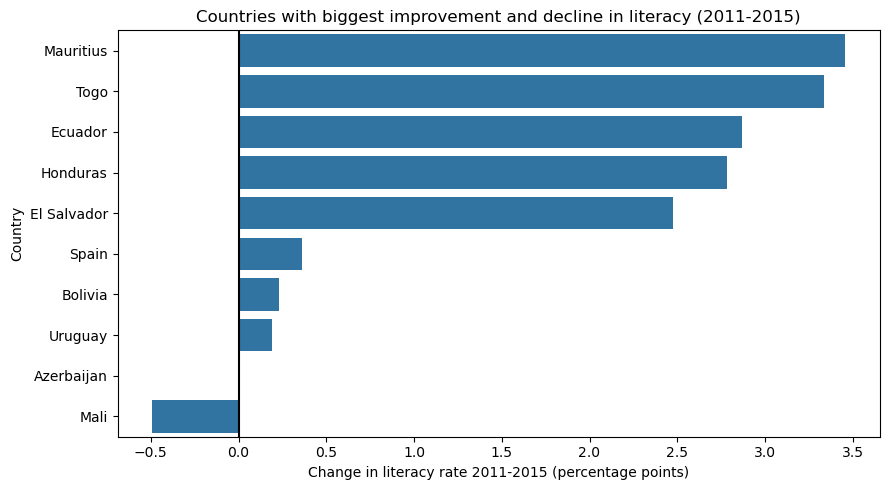

In [32]:
# visualization 2: top 5 improvers and bottom 5 decliners
top_bottom = pd.concat([change.head(5), change.tail(5)])

plt.figure(figsize=(9, 5))
sns.barplot(x="change", y="Short Name", data=top_bottom)
plt.xlabel("Change in literacy rate 2011-2015 (percentage points)")
plt.ylabel("Country")
plt.title("Countries with biggest improvement and decline in literacy (2011-2015)")
plt.axvline(0, color="black")
plt.tight_layout()
plt.show()

### Task 1: Setting up an API key and .env file

In [33]:
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")

28d00...


### Task 2: Retrieving data from MarketStack

In [35]:
# A: Retrieves End-of-Day (eod) data for these five stocks for March 2026
import requests

url = "https://api.marketstack.com/v1/eod"
params = {
    "access_key": api_key,
    "symbols": "META,AAPL,AMZN,NFLX,GOOG",
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "limit": 1000,
}

response = requests.get(url, params=params)
stock_data = response.json()
print("Number of records:", len(stock_data["data"]))

Number of records: 110


In [36]:
# B: Convert the retrieved JSON data into a pandas DataFrame
stocks_df = pd.DataFrame(stock_data["data"])
stocks_df["date"] = pd.to_datetime(stocks_df["date"]).dt.date
stocks_df = stocks_df[["symbol", "date", "open", "high", "low", "close", "volume"]].sort_values(["symbol", "date"])

stocks_df.head()

,symbol,date,open,high,low,close,volume
105,AAPL,2026-03-02,262.440,266.530,260.20,264.72,41576035.0
100,AAPL,2026-03-03,263.480,265.560,260.13,263.75,37994695.0
95,AAPL,2026-03-04,264.650,266.150,261.42,262.52,39258957.0
90,AAPL,2026-03-05,260.745,261.555,257.25,260.29,49424671.0
85,AAPL,2026-03-06,258.740,258.760,254.37,257.46,40628988.0


In [37]:
# C: Summary statistics for closing prices per stock
stocks_df.groupby("symbol")["close"].describe()

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [38]:
# returns percentages for each stock in March
returns = {}
for ticker in ["META", "AAPL", "AMZN", "NFLX", "GOOG"]:
    stock = stocks_df[stocks_df["symbol"] == ticker].sort_values("date")
    first_close = stock["close"].iloc[0]
    last_close = stock["close"].iloc[-1]
    returns[ticker] = (last_close - first_close) / first_close * 100

returns_df = pd.DataFrame(list(returns.items()), columns=["symbol", "return_pct"])
print(returns_df)

print("\nBest performer:", returns_df.loc[returns_df["return_pct"].idxmax(), "symbol"])
print("Worst performer:", returns_df.loc[returns_df["return_pct"].idxmin(), "symbol"])

  symbol  return_pct
0   META  -12.459453
1   AAPL   -4.128891
2   AMZN   -0.057584
3   NFLX   -0.968174
4   GOOG   -6.365061

Best performer: AMZN
Worst performer: META


### Task 3: Visualizing stock data

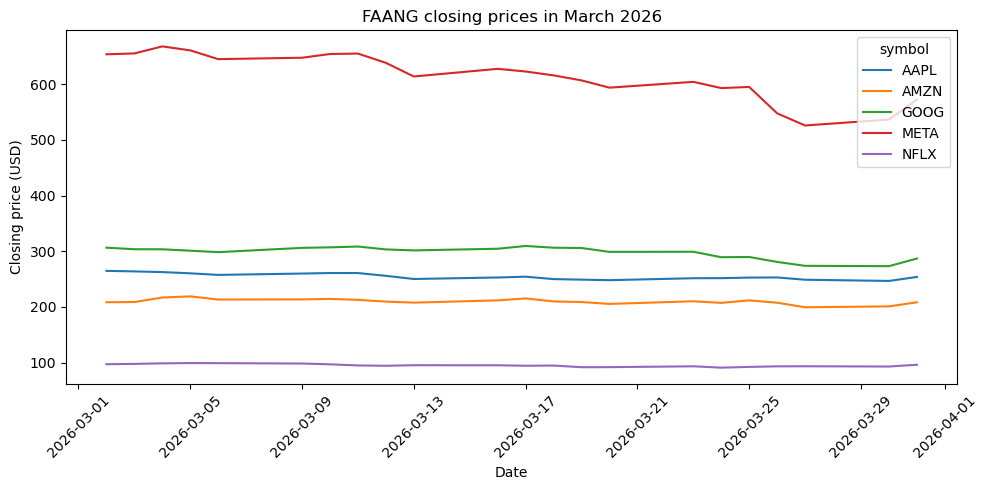

In [40]:
#A: Creates a line chart of the performance of the companies

plt.figure(figsize=(10, 5))
sns.lineplot(data=stocks_df, x="date", y="close", hue="symbol")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")
plt.title("FAANG closing prices in March 2026")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

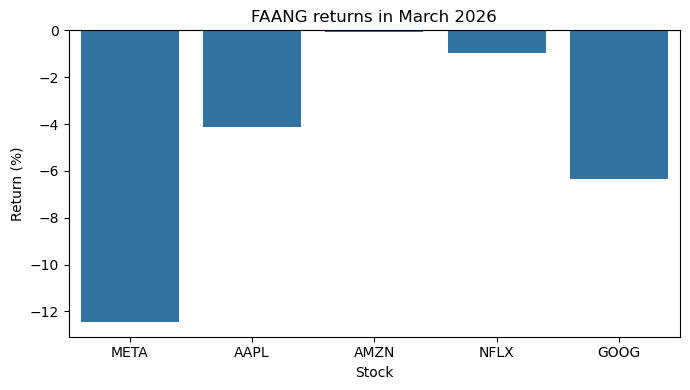

In [42]:
# B: A bar plot showing the overall return percentage for each stock

plt.figure(figsize=(7, 4))
sns.barplot(data=returns_df, x="symbol", y="return_pct")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.title("FAANG returns in March 2026")
plt.axhline(0, color="black")
plt.tight_layout()
plt.show()

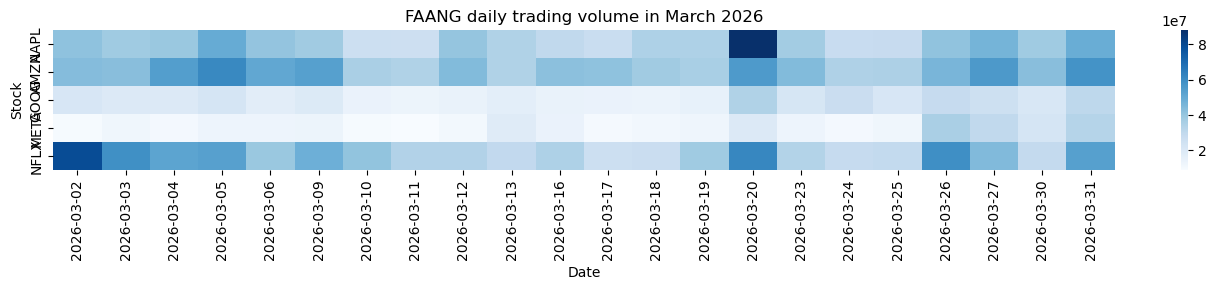

In [44]:
# A heatmap showing the daily trading volume for each stock 

volume_table = stocks_df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(14, 3))
sns.heatmap(volume_table, cmap="Blues")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.title("FAANG daily trading volume in March 2026")
plt.tight_layout()
plt.show()

### Task 4: Exporting and importing data

In [46]:
# A: Exporting JSON data retrieved in Task 2a as a JSON file into exports folder

import json
import os

os.makedirs("exports", exist_ok=True)

with open("exports/stockdata.json", "w") as f:
    json.dump(stock_data, f)

In [47]:
# B: Export the DataFrame from Task 2b as a CSV file into exports folder

stocks_df.to_csv("exports/stockdata.csv", index=False)

In [48]:
# C: Load back the two files

with open("exports/stockdata.json") as f:
    loaded_json = json.load(f)

loaded_csv = pd.read_csv("exports/stockdata.csv")

print("First 5 records from JSON:")
print(pd.DataFrame(loaded_json["data"]).head())

print("\nFirst 5 rows from CSV:")
print(loaded_csv.head())

First 5 records from JSON:
      open    high      low   close      volume  adj_high  adj_low  adj_close  \
0  247.890  255.48  247.101  253.79  48770963.0    255.48  247.101     253.79   
1  204.875  210.28  204.140  208.27  57843337.0    210.28  204.140     208.27   
2  277.840  287.05  276.810  286.86  30680107.0    287.05  276.760     286.86   
3  549.980  573.69  546.770  572.13  32809500.0    573.69  546.770     572.13   
4   93.250   96.26   93.170   96.15  53674277.0     96.26   93.030      96.15   

   adj_open  adj_volume  split_factor  dividend symbol exchange  \
0   247.910  49598091.0           1.0       0.0   AAPL     XNAS   
1   204.845  58470078.0           1.0       0.0   AMZN     XNAS   
2   277.540  31625057.0           1.0       0.0   GOOG     XNAS   
3   549.980  32898272.0           1.0       0.0   META     ARCX   
4    93.030  54269957.0           1.0       0.0   NFLX     XNAS   

                       date  
0  2026-03-31T00:00:00+0000  
1  2026-03-31T00:00:00+

### Task 5: Querying the Northwind database

In [49]:
# A: Connect to the database and list all tables it contains 

import sqlite3

conn = sqlite3.connect("northwind.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


In [50]:
# B: Write a SQL query that retrieves all products with a unit price above 30 

query = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""

products = pd.read_sql(query, conn)
print(products)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

In [52]:
# C: SQL query for all orders shipped to Germany

query = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS Total
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""

germany = pd.read_sql(query, conn)
print(germany.head())

          CompanyName  OrderID   OrderDate ShipCountry   Total
0  Toms Spezialitäten    10249  2016-07-05     Germany   167.4
1  Toms Spezialitäten    10249  2016-07-05     Germany  1696.0
2  Ottilies Käseladen    10260  2016-07-19     Germany   123.2
3  Ottilies Käseladen    10260  2016-07-19     Germany   780.0
4  Ottilies Käseladen    10260  2016-07-19     Germany   591.0


### Task 6: Visualizing Northwind data

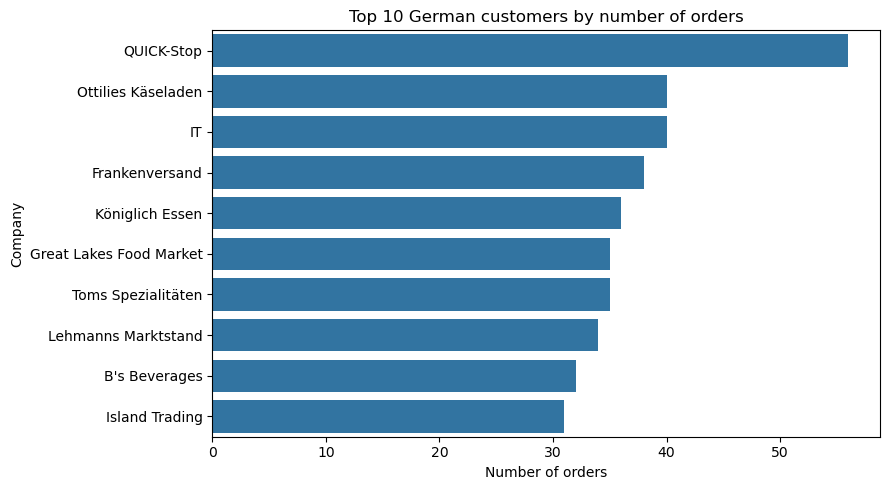

In [53]:
# A: creates a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany)

# counts distinct orders per customer
orders_per_customer = germany.drop_duplicates("OrderID").groupby("CompanyName").size()
orders_per_customer = orders_per_customer.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=orders_per_customer.values, y=orders_per_customer.index)
plt.xlabel("Number of orders")
plt.ylabel("Company")
plt.title("Top 10 German customers by number of orders")
plt.tight_layout()
plt.show()

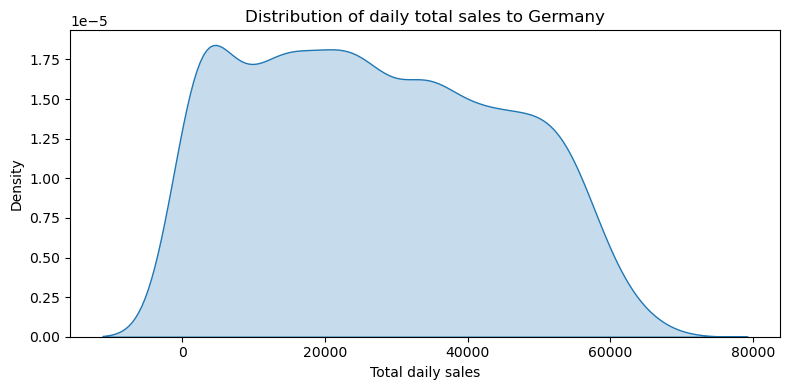

In [55]:
# B: Density plot of daily sales

daily_sales = germany.groupby("OrderDate")["Total"].sum()

plt.figure(figsize=(8, 4))
sns.kdeplot(daily_sales, fill=True)
plt.xlabel("Total daily sales")
plt.ylabel("Density")
plt.title("Distribution of daily total sales to Germany")
plt.tight_layout()
plt.show()

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1      Condiments   55802774.45
2     Confections   66347544.94
3  Dairy Products   58034940.00
4  Grains/Cereals   28573512.55
5    Meat/Poultry   64896314.41
6         Produce   32706403.90
7         Seafood   49931965.52


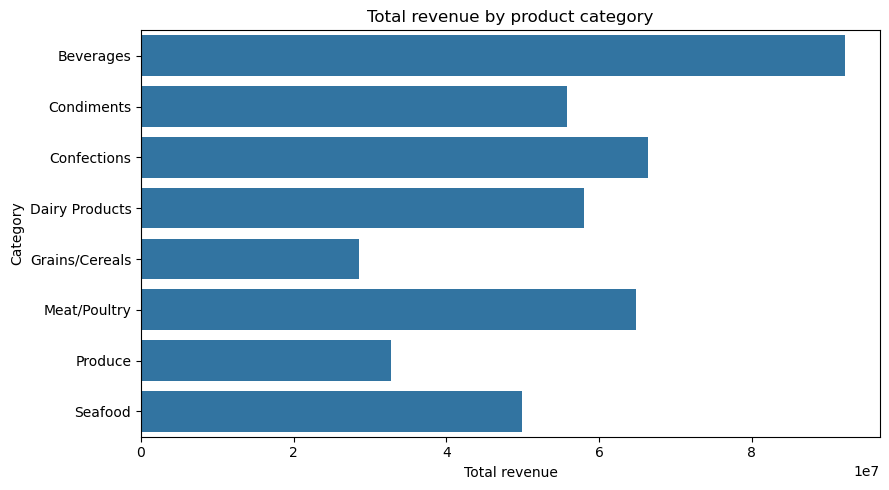

In [56]:
# C: Total revenue per category

query = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
"""

category_revenue = pd.read_sql(query, conn)
print(category_revenue)

plt.figure(figsize=(9, 5))
sns.barplot(data=category_revenue, x="TotalRevenue", y="CategoryName")
plt.xlabel("Total revenue")
plt.ylabel("Category")
plt.title("Total revenue by product category")
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL

In [57]:
# A: SQL query that retrieves the full Products table and the full Categories table

products_df = pd.read_sql("SELECT * FROM Products", conn)
categories_df = pd.read_sql("SELECT * FROM Categories", conn)

print("Products:")
print(products_df.head())
print("\nCategories:")
print(categories_df.head())

Products:
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4        

In [58]:
# B: using Pandas and inner join

joined = products_df.merge(categories_df, on="CategoryID", how="inner")
print(joined.head())

   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued CategoryName  \
0            0    Beverages   
1            0    Beverages   
2          

In [62]:
# C: Comparing SQL and Python pandas

import time

# SQL version (same as 6c)
start = time.time()
sql_result = pd.read_sql("""
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
""", conn)
sql_time = time.time() - start

# pandas version
start = time.time()
order_details = pd.read_sql("SELECT * FROM 'Order Details'", conn)
products = pd.read_sql("SELECT * FROM Products", conn)
categories = pd.read_sql("SELECT * FROM Categories", conn)

merged = order_details.merge(products, on="ProductID").merge(categories, on="CategoryID")
# both Order Details and Products have a UnitPrice column, so pandas renames them
# UnitPrice_x (from Order Details) and UnitPrice_y (from Products). We want the one from Order Details.
merged["LineTotal"] = merged["UnitPrice_x"] * merged["Quantity"]
pandas_result = merged.groupby("CategoryName")["LineTotal"].sum().reset_index()
pandas_time = time.time() - start

print("SQL time:", sql_time, "seconds")
print("Pandas time:", pandas_time, "seconds")

SQL time: 1.1144115924835205 seconds
Pandas time: 1.926912546157837 seconds


SQL was faster because it does the join and the sum directly in the database and only returns the final small result.

In [65]:
# Closing the connection to the database

conn.close()

### Task 8: Wide and long format

In [66]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [67]:
# A: Converting wide to long format

print("Before:")
print(wide_data)

wide_long = pd.melt(wide_data, id_vars="store", var_name="quarter", value_name="sales")

print("\nAfter:")
print(wide_long)

Before:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

After:
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


In [69]:
# B: Converting long to wide format

print("Before:")
print(long_data)

long_wide = long_data.pivot(index="month", columns="product", values="units_sold").reset_index()

print("\nAfter:")
print(long_wide)

Before:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

After:
product month  Laptop  Phone
0         Feb      50    110
1         Jan      45    120
2         Mar      55    130


#### c: Converts both back

In [71]:
# long back to wide
back_to_wide = wide_long.pivot(index="store", columns="quarter", values="sales").reset_index()
back_to_wide.columns.name = None

print("Back to wide (should match the original wide_data):")
print(back_to_wide)

Back to wide (should match the original wide_data):
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500


In [73]:
# wide back to long
back_to_long = pd.melt(long_wide, id_vars="month", var_name="product", value_name="units_sold")

print("Back to long (should match the original long_data):")
print(back_to_long)

Back to long (should match the original long_data):
  month product  units_sold
0   Feb  Laptop          50
1   Jan  Laptop          45
2   Mar  Laptop          55
3   Feb   Phone         110
4   Jan   Phone         120
5   Mar   Phone         130
